In [64]:

from dotenv import load_dotenv
from pathlib import Path
import base64
import PIL.Image
from IPython.display import display
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage

load_dotenv()
gemini = init_chat_model("gemini-2.5-flash", model_provider="google_genai")
qwen = init_chat_model("Qwen/Qwen3.5-9B", model_provider="together")
gemma = init_chat_model("google/gemma-4-31B-it", model_provider="together")

def caption(prompt, img_path):
    data = base64.b64encode(Path(img_path).read_bytes()).decode()
    msg = [HumanMessage(content=[
        {"type": "text", "text": prompt},
        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{data}"}},
    ])]
    return gemma.invoke(msg).content
    

In [65]:

# clear interactions
sample1 = ["obs_340433312_photo_619519266", "obs_340368188_photo_619383348", "obs_340364592_photo_619375042", "obs_340514310_photo_619679014"]

# ambiguous interactions (ocean plants)
sample2 = ["obs_250956763_photo_448935283", "obs_258568965_photo_463949088", "obs_102691691_photo_171703626", "obs_333144263_photo_501540234"]

# ambiguous interactions (plants)
sample3 = ["obs_323944435_photo_586236533", "obs_325625055_photo_589595206", "obs_331752340_photo_601901044", "obs_331831594_photo_602051260"]

# ambiguous interactions (animals)
sample4 = ["obs_64497720_photo_103704678", "obs_340514309_photo_619678757", "obs_338486970_photo_615576074", "obs_188731534_photo_330410184"]

sample = sample4


In [66]:

prompt1 = "Write one concise alt-text sentence describing what is feeding on what."
prompt2 = "Generate a one concise alt-text sentence describing what is feeding on what."
prompt3 = "Write one concise alt-text sentence describing who eats whom."
prompt4 = "This image likely shows a feeding interaction between two species. If so, describe who eats whom. Write a concise description for someone using a screen reader."
prompt = prompt1


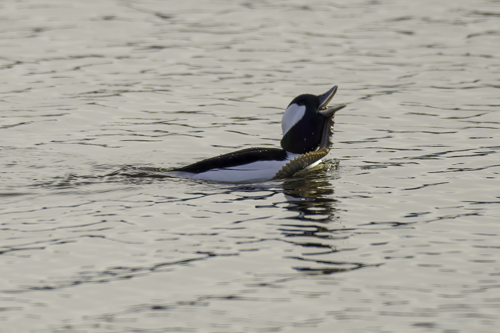

A duck feeds on a fish.




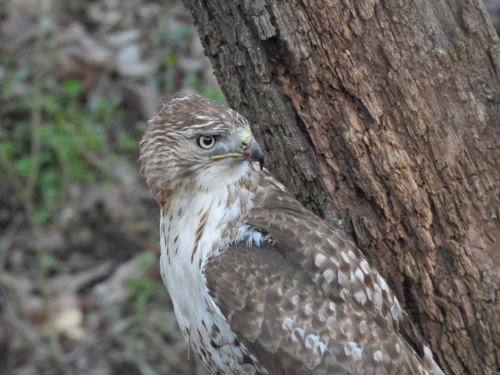

A hawk is feeding on a small piece of prey.




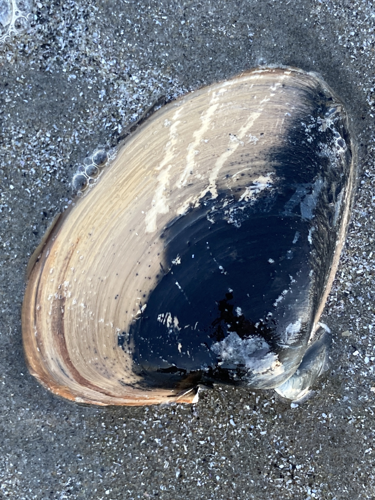

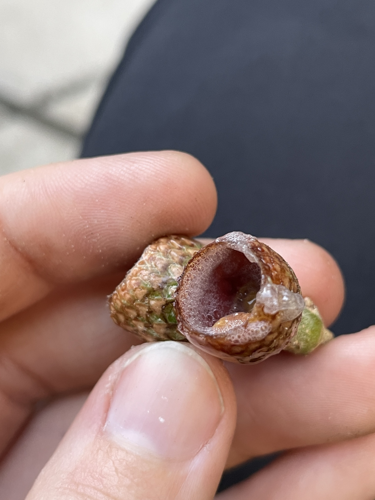

A small larva feeds inside a brown plant gall.




In [67]:

for name in sample:
    img_path = f"images/{name}.jpg"
    img = PIL.Image.open(img_path)
    img.thumbnail((500, 500))
    display(img)
    result = caption(prompt, img_path)     
    print(result)      
    print("\n")
